# CYBER-RISK INTELLIGENCE (PARTE I): ANÁLISIS DESCRIPTIVO Y MAPEO ESTRATÉGICO DEL DELITO INFORMÁTICO
Autor: Julián Esteban León Ospina

Fase: Exploratory Data Analysis (EDA) & Spatial Analytics

Este notebook desarrolla una auditoría profunda sobre la infraestructura delictiva digital en Colombia. A través de un análisis espacial y descriptivo exhaustivo, se identifican los nodos críticos de vulnerabilidad y la evolución de los delitos tradicionales hacia modalidades cibernéticas, estableciendo los patrones de comportamiento necesarios para el entrenamiento de modelos de detección avanzada.

## TRATAMIENTO DE DATOS Y MEDIDAS DE ESTANDARIZACIÓN PROTOCOLARIAS.


In [1]:
# 1. LIBRERÍAS (Tus originales + Potencia de ML)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import holidays
import geopandas as gpd
import plotly.express as px
from dython.nominal import associations
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.patches as mpatches
from scipy import stats
import squarify
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score



warnings.filterwarnings('ignore')
plt.style.use('ggplot')

c:\miniconda\envs\forecasting\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Librerías para análisis de datos, visualización, modelado y evaluación de modelos.

In [2]:
# 2. CARGA Y LIMPIEZA INICIAL (Tu lógica de del_fros.ipynb)
ruta_archivo = "C:/Users/Julián E León O/Desktop/VARIOS/NODO_FORTE/Nodo_Acelerador/RETOS/PROYECTO_FINAL/final_zip/Conductas D.Informático _DELITOS_data.csv"
# Cargar el archivo con separador de punto y coma
df = pd.read_csv(ruta_archivo, sep=";")

df.columns = [col.lower().replace(' ', '_') for col in df.columns]
df = df.dropna()



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186050 entries, 0 to 186049
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   año                   186050 non-null  int64 
 1   cantidad              186050 non-null  int64 
 2   cod_dpto              186050 non-null  int64 
 3   cod_mun               186050 non-null  int64 
 4   departamento          186050 non-null  object
 5   descripcion_conducta  186050 non-null  object
 6   mes                   186050 non-null  object
 7   modalidad             186050 non-null  object
 8   modalidad_con         186050 non-null  object
 9   municipio             186050 non-null  object
 10  pais                  186050 non-null  object
 11  tipo                  186050 non-null  object
dtypes: int64(4), object(8)
memory usage: 17.0+ MB


In [4]:
# ESTANDARIZACIÓN DE LOS DATOS.


# --- Estandarizar encabezados ---
df.columns = (
    df.columns
    .str.lower()                                        # convertir a minúsculas
    .str.strip()                                        # eliminar espacios al inicio y al final
    .str.replace(r"\s+", "_", regex=True)               # reemplazar múltiples espacios por un solo guion bajo
)

# --- Estandarizar observaciones en variables categóricas ---
categoricas = df.select_dtypes(include=["object", "category"]).columns

for col in categoricas:
    df[col] = (
        df[col]
        .str.lower()                                    # convertir a minúsculas
        .str.strip()                                    # eliminar espacios al inicio y al final
        .str.replace(r"\s+", " ", regex=True)           # reemplazar múltiples espacios por uno solo
    )

# Verificar cambios
df.head(3)


,año,cantidad,cod_dpto,cod_mun,departamento,descripcion_conducta,mes,modalidad,modalidad_con,municipio,pais,tipo
0,2020,1,5,5001,antioquia,artículo 269a. acceso abusivo a un sistema inf...,ene,"correo electronico y redes sociales spam, scam",suplantación,medellín,colombia,di
1,2020,1,5,5001,antioquia,artículo 269a. acceso abusivo a un sistema inf...,ene,"correo electronico y redes sociales spam, scam",suplantación,medellín,colombia,di
2,2020,1,5,5001,antioquia,artículo 269a. acceso abusivo a un sistema inf...,ene,"correo electronico y redes sociales spam, scam",suplantación,medellín,colombia,di


In [5]:
# PROCESAMIENTO VALORES ÚNICOS EN VARIABLES CATEGÓRICAS.

# Seleccionar solo columnas categóricas (tipo object o categoría)
categoricas = df.select_dtypes(include=["object", "category"]).columns

# Mostrar valores únicos de cada columna categórica
for col in categoricas:
    print(f"\nValores únicos en la columna '{col}':")
    print(df[col].unique())



Valores únicos en la columna 'departamento':
['antioquia' 'atlántico' 'bogotá' 'bolívar' 'caldas' 'cauca' 'cesar'
 'cundinamarca' 'huila' 'magdalena' 'meta' 'nariño' 'norte de santander'
 'santander' 'sucre' 'tolima' 'valle' 'casanare' 'putumayo' 'boyacá'
 'caquetá' 'córdoba' 'guajira' 'quindío' 'risaralda' 'guaviare' 'arauca'
 'chocó' 'vaupés' 'san andrés' 'amazonas' 'guainía' 'vichada']

Valores únicos en la columna 'descripcion_conducta':
['artículo 269a. acceso abusivo a un sistema informático'
 'artículo 269i. hurto por medios informáticos y semejantes'
 'artículo 269c. interceptación de datos informáticos'
 'artículo 269f. violación de datos personales'
 'artículo 269j. transferencia no consentida de activos'
 'artículo 269g. suplantación de sitios web para capturar datos personales']

Valores únicos en la columna 'mes':
['ene' 'feb' 'jul' 'may' 'nov' 'oct' 'sep' 'jun' 'mar' 'abr' 'ago' 'dic']

Valores únicos en la columna 'modalidad':
['correo electronico y redes sociales spam,

In [6]:
# Renombrar observaciones en variable "modalidad"

df.loc[df['modalidad'] == '-', 'modalidad'] = 'desconocido'
df.loc[df['modalidad'] == 'no_reportada', 'modalidad'] = 'desconocido'

In [7]:

# Diccionario con abreviaturas de meses en español
meses_abrev = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4,
    "may": 5, "jun": 6, "jul": 7, "ago": 8,
    "sep": 9, "oct": 10, "nov": 11, "dic": 12
}

# Crear columna con número de mes
df["mes_num"] = df["mes"].str.lower().map(meses_abrev)

# Crear columna de fecha (día 1 como referencia)
df["fecha"] = pd.to_datetime(dict(year=df["año"], month=df["mes_num"], day=1))

# Verificar
print(df[["año", "mes", "fecha"]].head())

# Extracción de componentes temporales
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['fecha'].dt.month.apply(lambda x: 1 if x <= 6 else 2)
print("   ✓ Variables temporales creadas: Anio, Mes, Trimestre, Semestre")

#  Nombre del mes (útil para visualizaciones)
df['mes_nombre'] = df['fecha'].dt.month_name()
print("   ✓ mes_nombre creado")



    año  mes      fecha
0  2020  ene 2020-01-01
1  2020  ene 2020-01-01
2  2020  ene 2020-01-01
3  2020  ene 2020-01-01
4  2020  ene 2020-01-01
   ✓ Variables temporales creadas: Anio, Mes, Trimestre, Semestre
   ✓ mes_nombre creado


In [8]:
# REESTRUCTURACIÓN DEL SET DATOS: ELIMINAMOS COLUMNAS INNECESARIAS Y REORGANIZAMOS OTRAS PARA MEJORAR LA CLARIDAD Y USABILIDAD DEL DATASET.

# 1. Eliminamos las columnas 'año' y 'mes'
# Usamos 'errors=ignore' por seguridad en caso de que ya se hayan borrado
df.drop(columns=['año', 'mes'], inplace=True, errors='ignore')

# 2. Reorganizamos para que 'fecha' sea la primera columna
# Creamos una lista con 'fecha' al inicio y el resto de columnas después
cols = ['fecha'] + [col for col in df.columns if col != 'fecha']
df = df[cols]

# Mostramos el resultado de la estructura.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186050 entries, 0 to 186049
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   fecha                 186050 non-null  datetime64[ns]
 1   cantidad              186050 non-null  int64         
 2   cod_dpto              186050 non-null  int64         
 3   cod_mun               186050 non-null  int64         
 4   departamento          186050 non-null  object        
 5   descripcion_conducta  186050 non-null  object        
 6   modalidad             186050 non-null  object        
 7   modalidad_con         186050 non-null  object        
 8   municipio             186050 non-null  object        
 9   pais                  186050 non-null  object        
 10  tipo                  186050 non-null  object        
 11  mes_num               186050 non-null  int64         
 12  anio                  186050 non-null  int32         
 13 

Métodos de estandarización de datos:
- Estandarización de encabezados: Convertir a minúsculas, eliminar espacios y reemplazar espacios por guiones bajos.
- Estandarización de observaciones en variables categóricas: Convertir a minúsculas, eliminar espacios al inicio y al final y  reemplazar múltiples espacios por uno solo.  
- Renombrar observaciones en variable "modalidad": Reemplazar valores '-' y 'no_reportada' por 'desconocido'.   
- Inspección de valores únicos en variables categóricas para identificar inconsistencias o errores de tipeo.

## ANÁLISIS EXPLORATORIO Y VISUAL.


In [9]:
# OUTLIERS EN LA VARIABLE CLAVE: CANTIDAD.

# Función para detectar outliers con IQR
def detectar_outliers_iqr(data, columna, factor=1.5):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1

    valla_inferior = Q1 - factor * IQR
    valla_superior = Q3 + factor * IQR

    outliers = (data[columna] < valla_inferior) | (data[columna] > valla_superior)

    return outliers, valla_inferior, valla_superior

# Aplicar a puntajes de Matemáticas
outliers_mat, v_inf, v_sup = detectar_outliers_iqr(df, 'cantidad')

print(f"Outliers detectados en cantidad: {outliers_mat.sum()}")
print(f"Porcentaje: {outliers_mat.sum() / len(df) * 100:.2f}%")
print(f"Valla inferior: {v_inf:.2f}")
print(f"Valla superior: {v_sup:.2f}")

Outliers detectados en cantidad: 46041
Porcentaje: 24.75%
Valla inferior: 1.00
Valla superior: 1.00


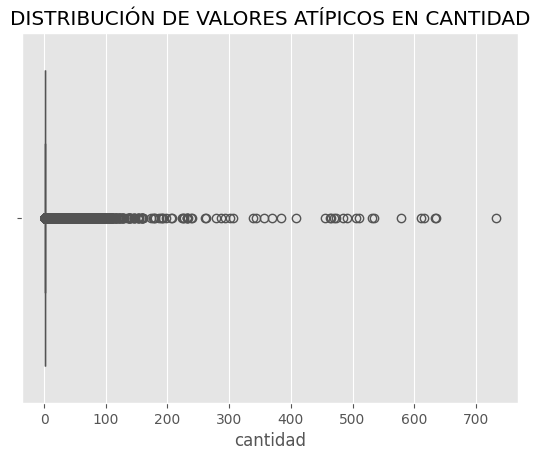

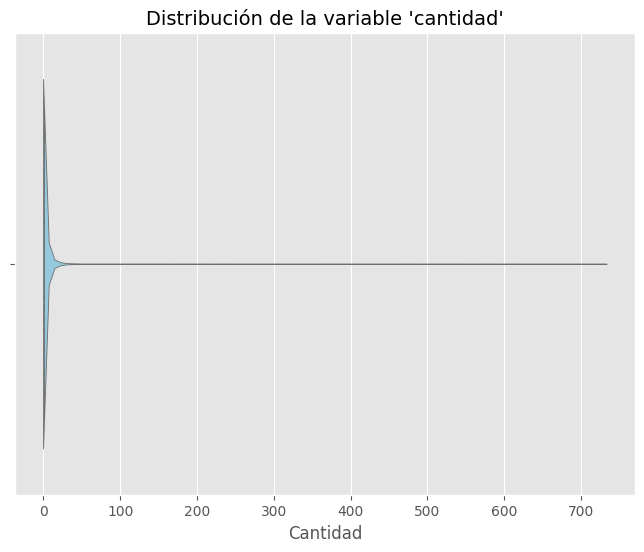

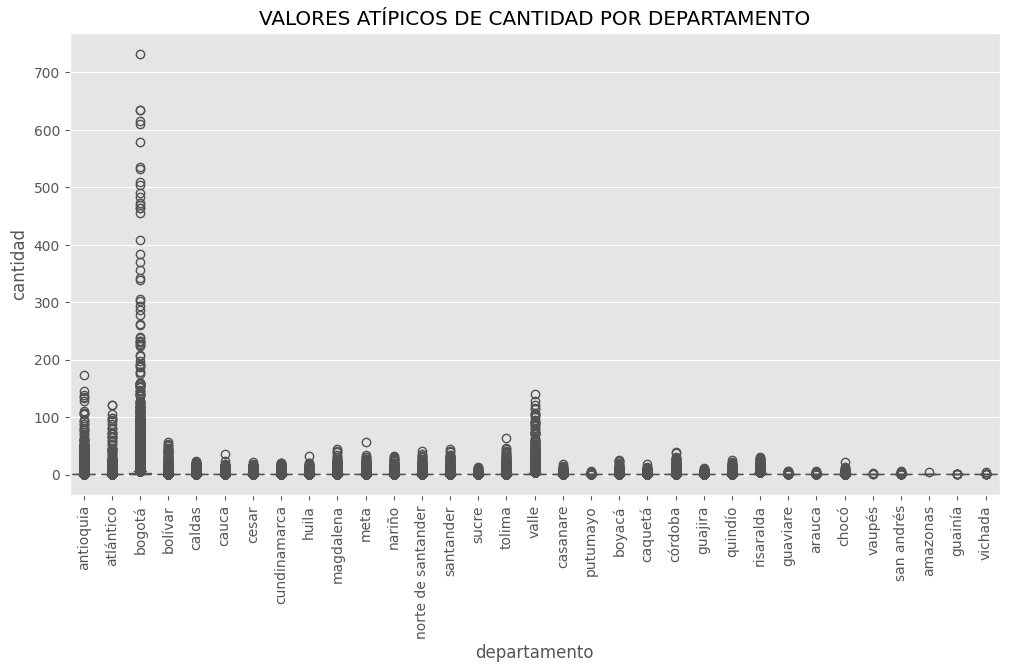

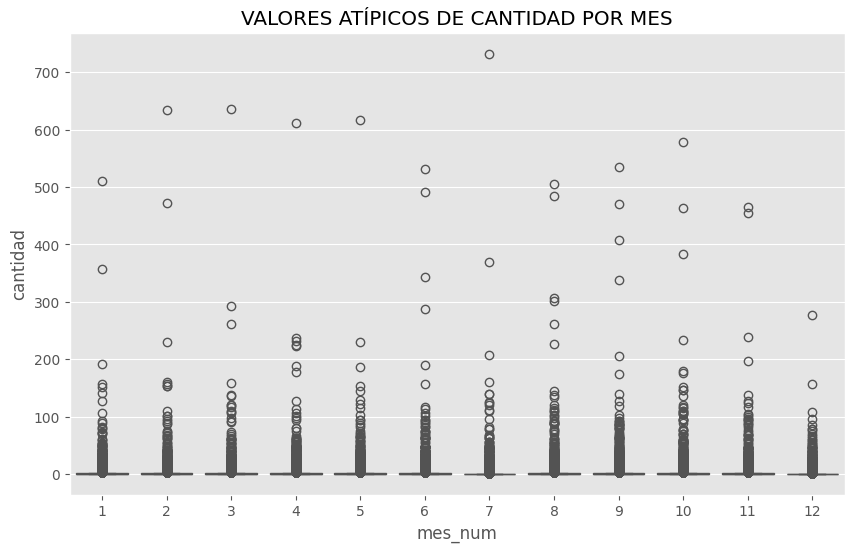

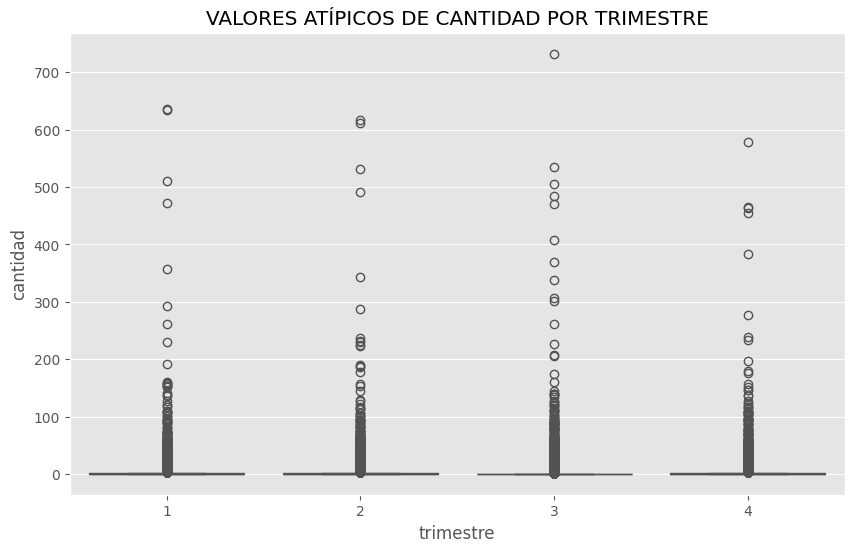

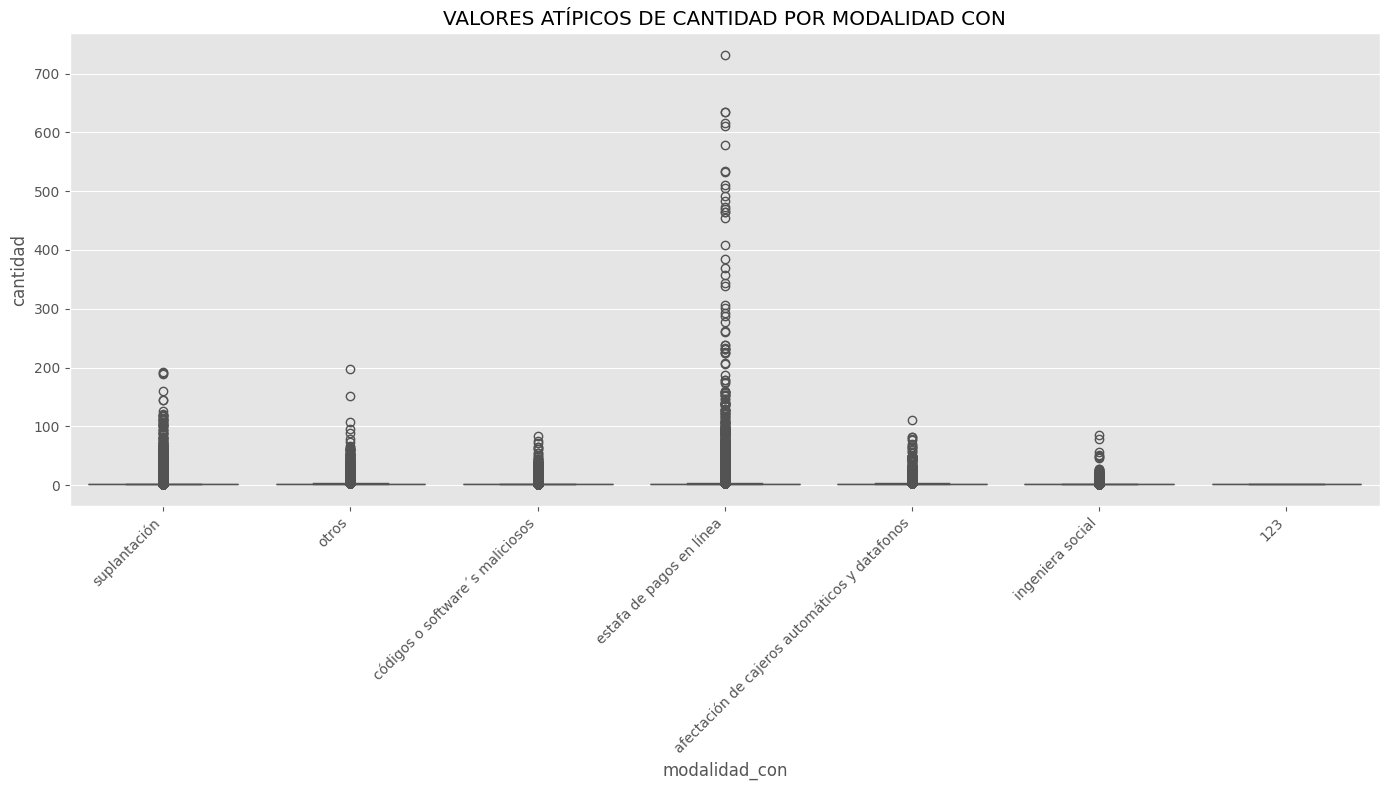

In [10]:
# DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS) EN LA VARIABLE "CANTIDAD" Y SU DISTRIBUCIÓN POR DEPARTAMENTO Y MES.

# Boxplot simple de la variable cantidad
sns.boxplot(x=df["cantidad"])
plt.title("DISTRIBUCIÓN DE VALORES ATÍPICOS EN CANTIDAD")
plt.show()


#Violin plot para visualizar la distribución de la variable cantidad
plt.figure(figsize=(8, 6))
sns.violinplot(x=df["cantidad"], inner="quartile", color="skyblue")
plt.title("Distribución de la variable 'cantidad'", fontsize=14)
plt.xlabel("Cantidad", fontsize=12)
plt.show()



# Boxplot agrupado por departamento
plt.figure(figsize=(12,6))
sns.boxplot(x="departamento", y="cantidad", data=df)
plt.xticks(rotation=90)
plt.title("VALORES ATÍPICOS DE CANTIDAD POR DEPARTAMENTO")
plt.show()

# Boxplot agrupado por mes
plt.figure(figsize=(10,6))
sns.boxplot(x="mes_num", y="cantidad", data=df)
plt.title("VALORES ATÍPICOS DE CANTIDAD POR MES")
plt.show()

# Boxplot agrupado por trimestre
plt.figure(figsize=(10,6))
sns.boxplot(x="trimestre", y="cantidad", data=df)
plt.title("VALORES ATÍPICOS DE CANTIDAD POR TRIMESTRE")
plt.show()


# Boxplot agrupado por modalidad_con
plt.figure(figsize=(14,8))
sns.boxplot(x="modalidad_con", y="cantidad", data=df)
plt.xticks(rotation=45, ha="right")  # rotar etiquetas para evitar solapamiento
plt.title("VALORES ATÍPICOS DE CANTIDAD POR MODALIDAD CON")
plt.tight_layout()  # ajusta márgenes automáticamente
plt.show()



Gráficos de dispersión para entender la relación entre cantidad y otras variables resultan útiles para identificar patrones o tendencias en los datos, así como para detectar posibles outliers o agrupamientos que podrían influir en el análisis de la variable cantidad. Estos gráficos permiten visualizar cómo varía la cantidad a lo largo del tiempo (meses, trimestres, semestres) y si existen patrones estacionales o agrupamientos específicos que podrían ser relevantes para la modelización o para entender mejor el comportamiento de la variable cantidad en función del tiempo.

In [11]:
# Análisis de cantidad
print('=== Análisis de Tendencia Central y de Dispersión en la variable "cantidad" ===\n')

media_cantidad = df['cantidad'].mean()
mediana_cantidad = df['cantidad'].median()
moda_cantidad = df['cantidad'].mode()[0] # Tomamos el primer valor si hay múltiples modas
varianza_cantidad = df['cantidad'].var()
desv_estandar_cantidad = df['cantidad'].std()
min_cantidad = df['cantidad'].min()
max_cantidad = df['cantidad'].max()
rango_cantidad = max_cantidad - min_cantidad
iqr_cantidad = df['cantidad'].quantile(0.75) - df['cantidad'].quantile(0.25)


print(f"Media: {media_cantidad:.2f} hechos")
print(f"Mediana: {mediana_cantidad:.2f} hechos")
print(f"Moda: {moda_cantidad:.2f} hechos")
print(f"Varianza: {varianza_cantidad:.2f}")
print(f"Desv. Estándar: {desv_estandar_cantidad:.2f}")
print(f"Mínimo: {min_cantidad:.2f} hechos")
print(f"Máximo: {max_cantidad:.2f} hechos")
print(f"Rango: {rango_cantidad:.2f} hechos")
print(f"IQR: {iqr_cantidad:.2f} hechos")


=== Análisis de Tendencia Central y de Dispersión en la variable "cantidad" ===

Media: 2.11 hechos
Mediana: 1.00 hechos
Moda: 1.00 hechos
Varianza: 61.29
Desv. Estándar: 7.83
Mínimo: 1.00 hechos
Máximo: 732.00 hechos
Rango: 731.00 hechos
IQR: 0.00 hechos


Estadísticas de tendencia central y de dispersión en la variable "cantidad". Permite identificar la media, mediana, moda, varianza, desviación estándar, mínimo, máximo, rango e IQR de la cantidad de hechos registrados. Esto ayuda a entender la distribución de los datos y a detectar posibles valores atípicos.

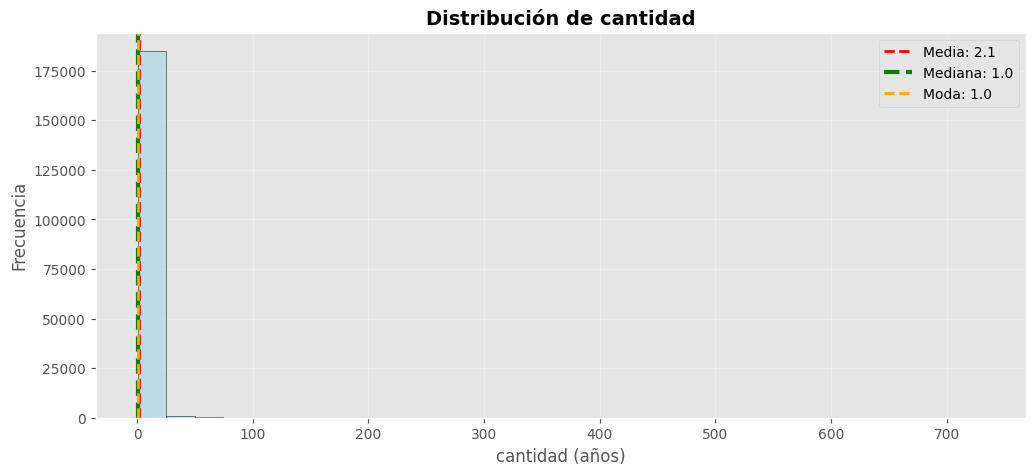


NOTA: Media (2.1), Moda (1.0) y Mediana (1.0) están muy cerca, por lo que las líneas pueden superponerse en el gráfico


In [12]:
# Visualizar distribución de cantidad
plt.figure(figsize=(12, 5))

plt.hist(df['cantidad'], bins=30, color='lightblue', edgecolor='black', alpha=0.7) # Histograma de cantidad
plt.axvline(media_cantidad, color='red', linestyle='--', linewidth=2, label=f'Media: {media_cantidad:.1f}') # axvline dibuja una línea vertical
plt.axvline(mediana_cantidad, color='green', linestyle='--', linewidth=3, label=f'Mediana: {mediana_cantidad:.1f}')
plt.axvline(moda_cantidad, color='orange', linestyle='--', linewidth=2, label=f'Moda: {moda_cantidad:.1f}')

plt.title('Distribución de cantidad', fontsize=14, fontweight='bold')
plt.xlabel('cantidad (años)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# La línea verde (mediana) puede estar oculta detrás de la línea naranja (moda) porque sus valores son muy similares
print(f"\nNOTA: Media ({media_cantidad:.1f}), Moda ({moda_cantidad:.1f}) y Mediana ({mediana_cantidad:.1f}) están muy cerca, por lo que las líneas pueden superponerse en el gráfico")

Histograma de frecuencias de cantidad con líneas de tendencia central (media, mediana, moda) para visualizar la distribución y la presencia de outliers. Utilizado para entender la dispersión y asimetría de la variable clave, así como para identificar posibles valores atípicos que puedan influir en el análisis.  
La presencia de una "cola larga" y una mediana de 1 confirma que el riesgo no es lineal, justificando la segmentación posterior para mejorar la ingesta del modelo.             

In [13]:
# Tablas de frecuencias realativa y absoluta para variables categóricas.


# Identificar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

# Crear tablas de frecuencias
for col in categorical_cols:
    print(f"\n Frecuencias para la variable: {col}\n")
    
    # Frecuencia absoluta
    freq_abs = df[col].value_counts()
    
    # Frecuencia relativa (porcentaje)
    freq_rel = df[col].value_counts(normalize=True) * 100
    
    # Combinar en una sola tabla
    freq_table = pd.DataFrame({
        'Frecuencia Absoluta': freq_abs,
        'Frecuencia Relativa (%)': freq_rel.round(2)
    })
    
    display(freq_table)



 Frecuencias para la variable: departamento



,Frecuencia Absoluta,Frecuencia Relativa (%)
departamento,,
bogotá,29017,15.60
antioquia,27713,14.90
cundinamarca,17703,9.52
valle,17610,9.47
santander,10024,5.39
atlántico,9382,5.04
boyacá,6260,3.36
norte de santander,5936,3.19
tolima,5500,2.96



 Frecuencias para la variable: descripcion_conducta



,Frecuencia Absoluta,Frecuencia Relativa (%)
descripcion_conducta,,
artículo 269i. hurto por medios informáticos y semejantes,71564,38.46
artículo 269a. acceso abusivo a un sistema informático,38733,20.82
artículo 269f. violación de datos personales,37984,20.42
artículo 269g. suplantación de sitios web para capturar datos personales,17311,9.30
artículo 269j. transferencia no consentida de activos,14239,7.65
artículo 269c. interceptación de datos informáticos,6219,3.34



 Frecuencias para la variable: modalidad



...

,Frecuencia Absoluta,Frecuencia Relativa (%)
pais,,
colombia,186050,100.0



 Frecuencias para la variable: tipo



,Frecuencia Absoluta,Frecuencia Relativa (%)
tipo,,
di,186050,100.0



 Frecuencias para la variable: mes_nombre



,Frecuencia Absoluta,Frecuencia Relativa (%)
mes_nombre,,
July,20634,11.09
October,16072,8.64
September,15724,8.45
August,15666,8.42
April,15611,8.39
November,15403,8.28
March,15213,8.18
May,15147,8.14
February,14951,8.04


Tablas de frecuencia acumulada según variables que permiten observar la participación que ayudan a  comprender el fenómeno a observar posteriormente.

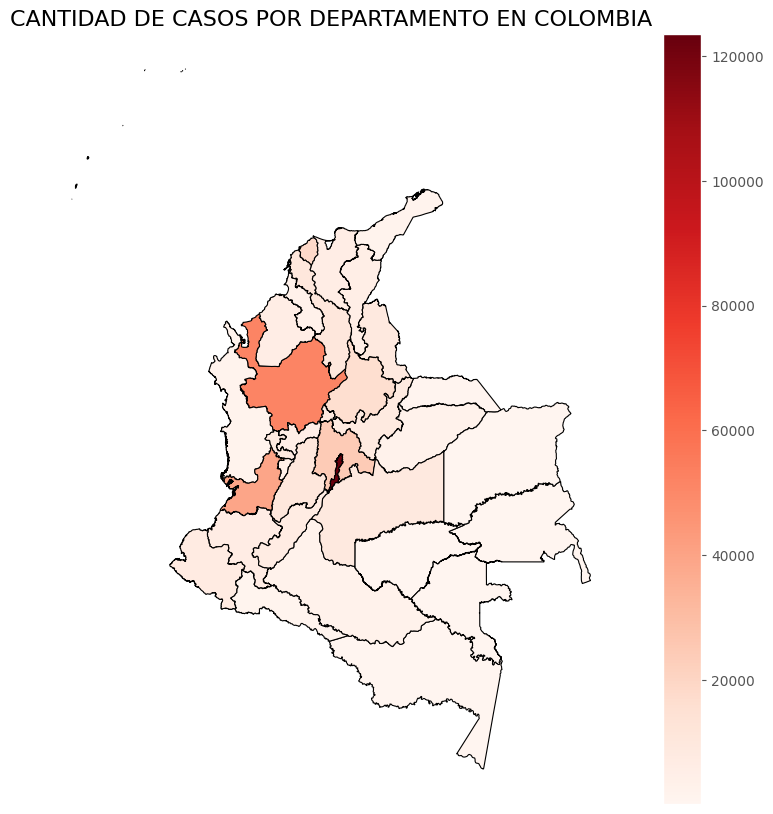

In [14]:
# CANTIDAD DE CASOS POR DEPARTAMENTO: MAPA COROPLETICO CON GEOJSON.

# 2. Agrupar por departamento
casos_por_dpto = df.groupby("departamento")["cantidad"].sum().reset_index()

# 3. Cargar el archivo GeoJSON
gdf = gpd.read_file("C:/Users/Julián E León O/Desktop/VARIOS/NODO_FORTE/Nodo_Acelerador/RETOS/PROYECTO_FINAL/gadm41_COL_1.json")

# 4. Normalizar nombres en ambos datasets
casos_por_dpto["departamento"] = casos_por_dpto["departamento"].str.lower().str.strip()
gdf["NAME_1"] = gdf["NAME_1"].str.lower().str.strip()

# 5. Crear diccionario de reemplazo para ajustar el GeoJSON a los nombres del CSV
mapeo_geojson = {
    "bogotád.c.": "bogotá",
    "laguajira": "guajira",
    "nortedesantander": "norte de santander",
    "sanandrésyprovidencia": "san andrés",
    "valledelcauca": "valle"
}

# 6. Aplicar el reemplazo en el GeoJSON
gdf["NAME_1"] = gdf["NAME_1"].replace(mapeo_geojson)

# 7. Hacer el merge con nombres corregidos
gdf = gdf.merge(casos_por_dpto, left_on="NAME_1", right_on="departamento", how="left")

# 8. Graficar
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf.plot(column="cantidad",
         cmap="Reds",
         linewidth=0.8,
         edgecolor="black",
         legend=True,
         ax=ax)

ax.set_title("CANTIDAD DE CASOS POR DEPARTAMENTO EN COLOMBIA", fontsize=16)
ax.axis("off")

plt.show()

Mapa coroplético que muestra la cantidad de casos por departamento en Colombia, utilizando un archivo GeoJSON para las fronteras administrativas. Permite visualizar la distribución geográfica de los casos y destacar las regiones con mayor incidencia.        

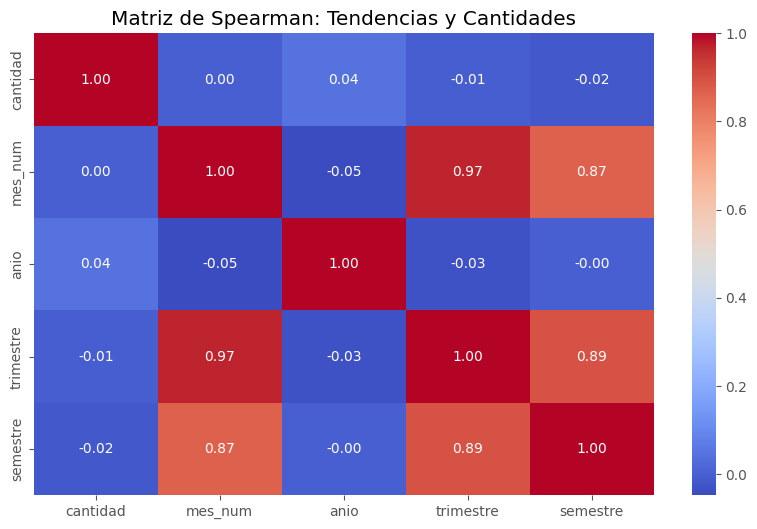

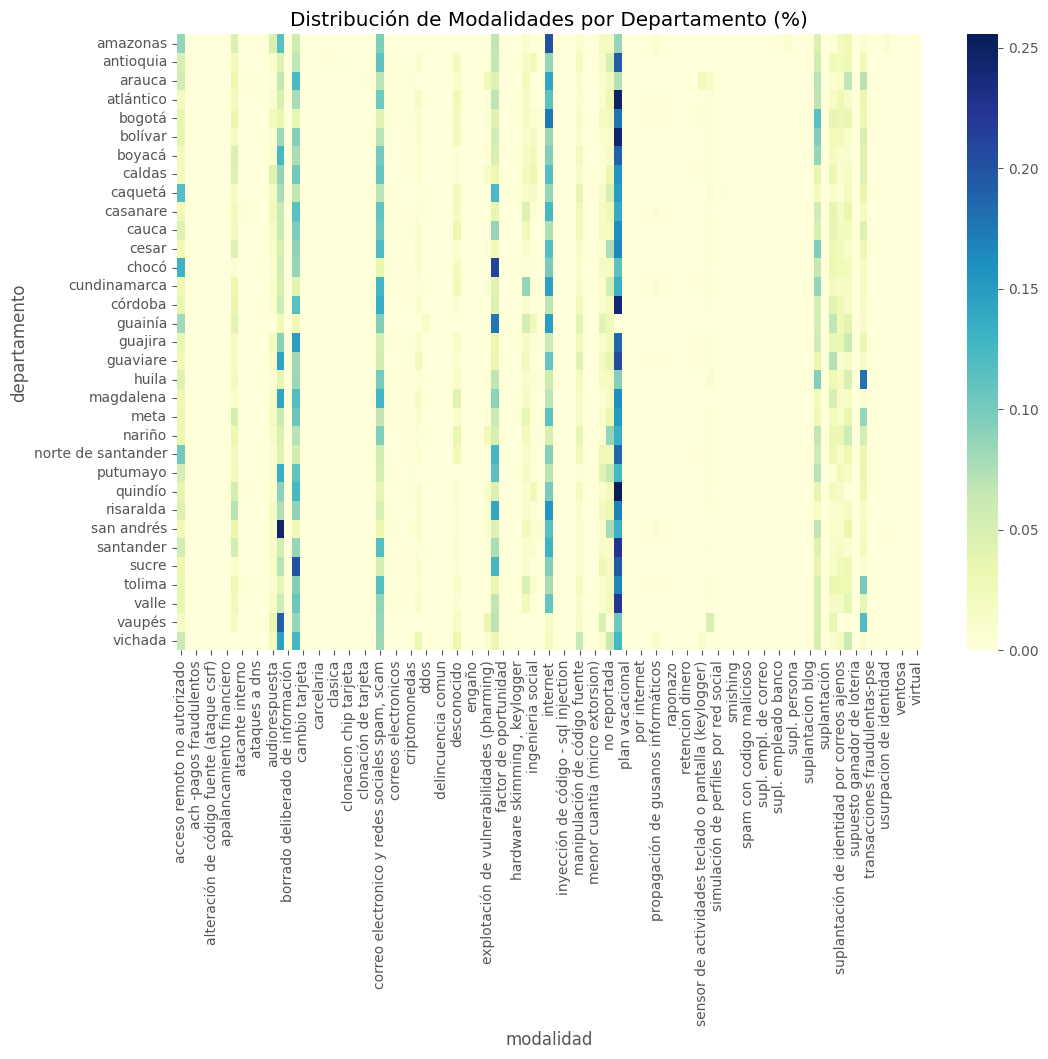

In [15]:

# 1. PREPARACIÓN: Seleccionamos columnas clave por tipo
cols_numericas = ['cantidad', 'mes_num', 'anio', 'trimestre', 'semestre']
cols_categoricas = ['departamento', 'tipo', 'modalidad', 'descripcion_conducta']

# --- MATRIZ 1: CORRELACIÓN DE SPEARMAN (Numérica/Ordinal) ---
plt.figure(figsize=(10, 6))
spearman_corr = df[cols_numericas].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Spearman: Tendencias y Cantidades")
plt.show()



# --- MATRIZ 2: HEATMAP DE FRECUENCIAS (Relación Categórica Específica) ---
# Útil para ver dónde se concentra el crimen por modalidad y departamento
plt.figure(figsize=(12, 8))
pivot_table = df.pivot_table(index='departamento', 
                             columns='modalidad', 
                             values='cantidad', 
                             aggfunc='sum').fillna(0)
# Normalizamos por filas para ver la distribución porcentual por dpto
pivot_norm = pivot_table.div(pivot_table.sum(axis=1), axis=0)

sns.heatmap(pivot_norm, cmap="YlGnBu", annot=False)
plt.title("Distribución de Modalidades por Departamento (%)")
plt.show()

Gráficos de correlaciones entre variables y variables de modalidad por departamento según cantidad.

In [16]:
################################################
# TABLA DE MOMENTUM Y CRECIMIENTO INTERANUAL   #
################################################


# 1. Agrupar por año y departamento
crecimiento = df.groupby(['anio', 'departamento'])['cantidad'].sum().unstack(level=0)

# 2. Calcular la variación porcentual entre los dos últimos años disponibles
años = sorted(df['anio'].unique())
if len(años) >= 2:
    col_ant, col_act = años[-2], años[-1]
    crecimiento['variacion_pct'] = ((crecimiento[col_act] - crecimiento[col_ant]) / crecimiento[col_ant]) * 100
    
    # 3. Clasificar
    def clasificar(row):
        if row['variacion_pct'] > 10: return 'Alerta Roja (Creciendo)'
        if row['variacion_pct'] < -10: return 'Mejorando (Bajando)'
        return 'Estable'

    crecimiento['estado'] = crecimiento.apply(clasificar, axis=1)

# Visualizar los 10 con mayor crecimiento
print(crecimiento.sort_values('variacion_pct', ascending=False).head(10))

anio            2018    2019    2020    2021    2022    2023    2024    2025  \
departamento                                                                   
amazonas        13.0    15.0    11.0    14.0     6.0     7.0    14.0    24.0   
vichada          5.0     5.0     7.0    12.0     5.0    13.0    19.0    30.0   
chocó          128.0   148.0   171.0   174.0   272.0   236.0   228.0   236.0   
cesar          225.0   220.0   782.0   653.0   913.0   749.0   935.0   945.0   
nariño         493.0   408.0   698.0   853.0   922.0   962.0  1502.0  1498.0   
santander     1102.0  1100.0  2077.0  2244.0  2452.0  2096.0  2541.0  2424.0   
córdoba        305.0   226.0   611.0   727.0   742.0   894.0  1348.0  1282.0   
cauca          383.0   337.0   718.0   884.0   843.0   969.0  1390.0  1288.0   
boyacá         471.0   441.0   725.0  1194.0  1465.0  1207.0  1506.0  1376.0   
meta           572.0   580.0   878.0   966.0  1432.0  1288.0  1721.0  1552.0   

anio          variacion_pct            

Tabla de crecimiento interanual por departamento que muestra el porcentaje de crecimiento o decrecimiento en la cantidad de casos entre los dos últimos años disponibles, junto con una clasificación de alerta roja (creciendo), mejorando (bajando) o estable.    

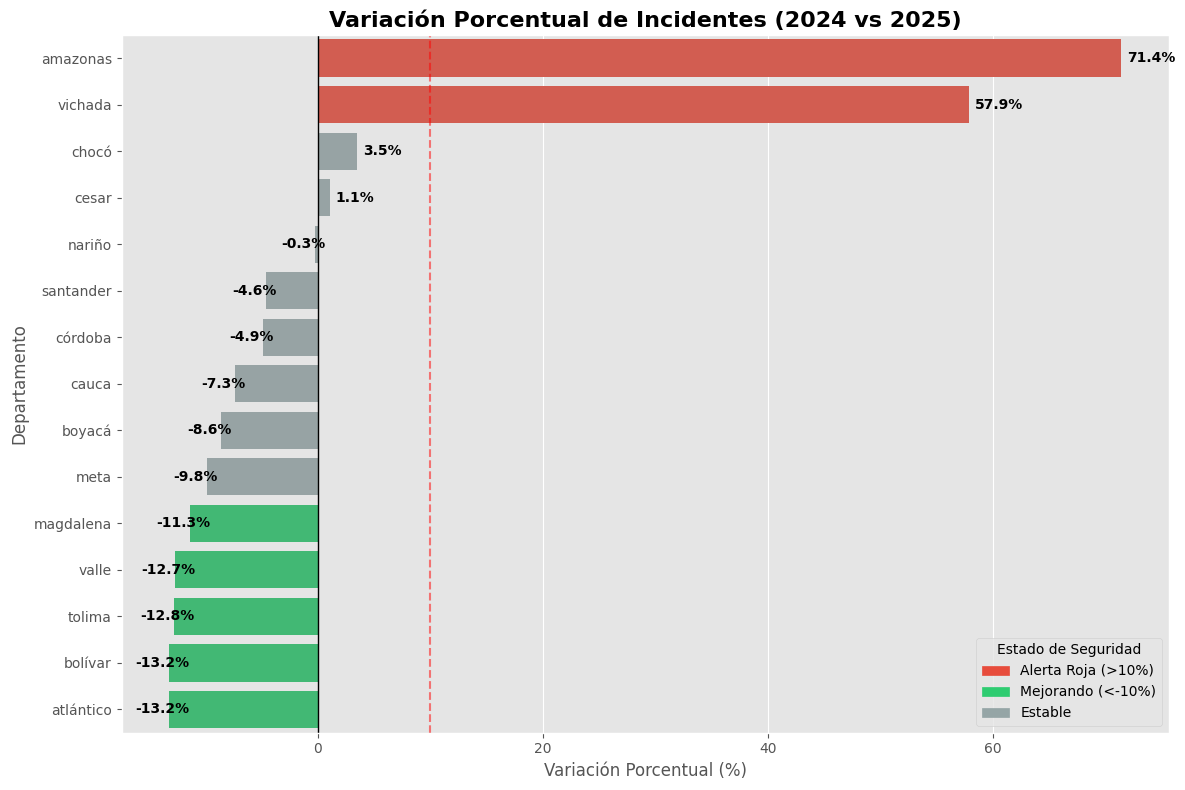

--- DETALLE DE MOMENTUM: 2024 vs 2025 ---
anio                   2024     2025  variacion_pct                   estado
departamento                                                                
amazonas               14.0     24.0      71.428571  Alerta Roja (Creciendo)
vichada                19.0     30.0      57.894737  Alerta Roja (Creciendo)
chocó                 228.0    236.0       3.508772                  Estable
cesar                 935.0    945.0       1.069519                  Estable
nariño               1502.0   1498.0      -0.266312                  Estable
santander            2541.0   2424.0      -4.604486                  Estable
córdoba              1348.0   1282.0      -4.896142                  Estable
cauca                1390.0   1288.0      -7.338129                  Estable
boyacá               1506.0   1376.0      -8.632138                  Estable
meta                 1721.0   1552.0      -9.819872                  Estable
magdalena            1210.0   1073

In [17]:


########################################################
# VISUALIZACIÓN DE MOMENTUM Y CRECIMIENTO INTERANUAL   #
########################################################

# 1. Preparar datos para la visualización (Top 10 Crecimiento y Top 10 Decrecimiento)
top_crecimiento = crecimiento.sort_values('variacion_pct', ascending=False).head(10)
top_mejora = crecimiento.sort_values('variacion_pct', ascending=True).head(10)

# 2. Configurar la figura
fig, ax = plt.subplots(figsize=(12, 8))

# 3. Crear colores basados en el estado
# Rojo para crecimiento, Verde para mejora, Gris para estable
colores = crecimiento.sort_values('variacion_pct', ascending=False)['estado'].map({
    'Alerta Roja (Creciendo)': '#e74c3c',
    'Mejorando (Bajando)': '#2ecc71',
    'Estable': '#95a5a6'
}).head(15) # Tomamos los primeros 15 para la gráfica

# 4. Gráfico de Barras de Variación Porcentual
datos_plot = crecimiento.sort_values('variacion_pct', ascending=False).head(15)
sns.barplot(
    x=datos_plot['variacion_pct'], 
    y=datos_plot.index, 
    palette=colores.tolist(),
    ax=ax
)

# 5. Personalización estética
plt.title(f'Variación Porcentual de Incidentes ({col_ant} vs {col_act})', fontsize=16, fontweight='bold')
plt.xlabel('Variación Porcentual (%)', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea en el 0
plt.axvline(x=10, color='red', linestyle='--', alpha=0.5)   # Línea de alerta

# Añadir etiquetas de porcentaje al final de cada barra
for i, v in enumerate(datos_plot['variacion_pct']):
    ax.text(v + 0.5 if v > 0 else v - 3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Leyenda manual para los estados
re_patch = mpatches.Patch(color='#e74c3c', label='Alerta Roja (>10%)')
gr_patch = mpatches.Patch(color='#2ecc71', label='Mejorando (<-10%)')
st_patch = mpatches.Patch(color='#95a5a6', label='Estable')
plt.legend(handles=[re_patch, gr_patch, st_patch], loc='lower right', title="Estado de Seguridad")

plt.tight_layout()
plt.show()

#######################################################
# TABLA VISUAL DE AUDITORÍA (ESTADO POR DEPARTAMENTO) #
#######################################################
# Mostramos los departamentos con sus volúmenes reales y el % de cambio
print(f"--- DETALLE DE MOMENTUM: {col_ant} vs {col_act} ---")
tabla_resumen = crecimiento[[col_ant, col_act, 'variacion_pct', 'estado']].sort_values('variacion_pct', ascending=False)
print(tabla_resumen.to_string())

Tabla y gráfico de momentum y crecimiento interanual por departamento, con clasificación de estado (Alerta Roja, Mejorando, Estable) basada en la variación porcentual entre los dos últimos años disponibles.

In [19]:
# Segmentación por Trimestre y Departamento para ver el Top 3 de cada uno
top_deptos_trimestre = df.groupby(['trimestre', 'departamento'])['cantidad'].sum().reset_index()
top_deptos_trimestre = top_deptos_trimestre.sort_values(['trimestre', 'cantidad'], ascending=[True, False])

# Mostramos solo los 3 departamentos con más casos por cada trimestre
print(top_deptos_trimestre.groupby('trimestre').head(3))

     trimestre departamento  cantidad
4            1       bogotá     29961
1            1    antioquia     12035
30           1        valle      9470
37           2       bogotá     30239
34           2    antioquia     12607
63           2        valle      9619
70           3       bogotá     33268
67           3    antioquia     14850
96           3        valle     10556
103          4       bogotá     30093
100          4    antioquia     12519
129          4        valle      9584


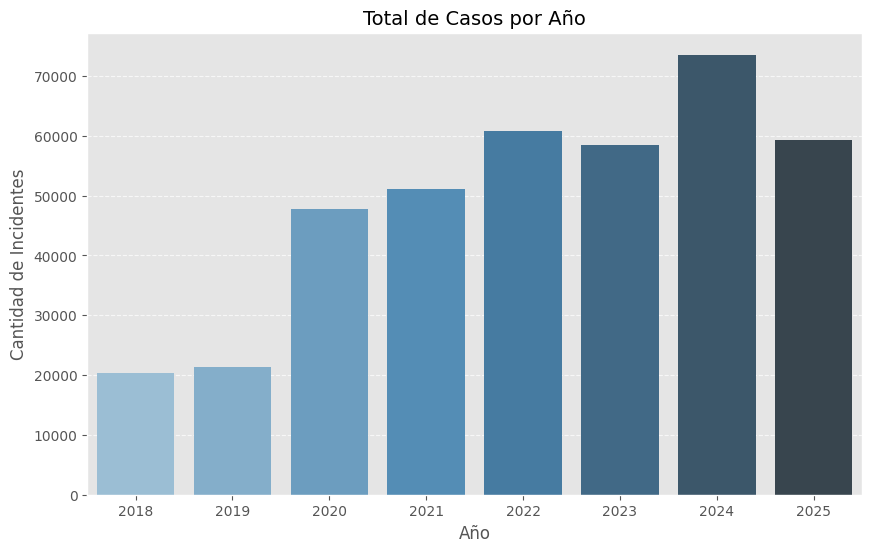

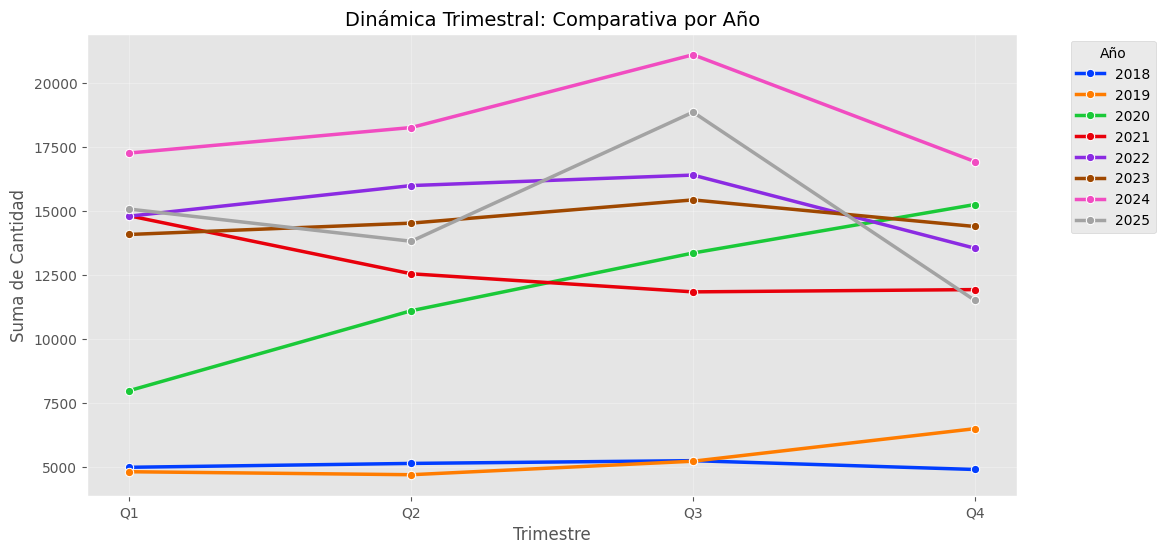

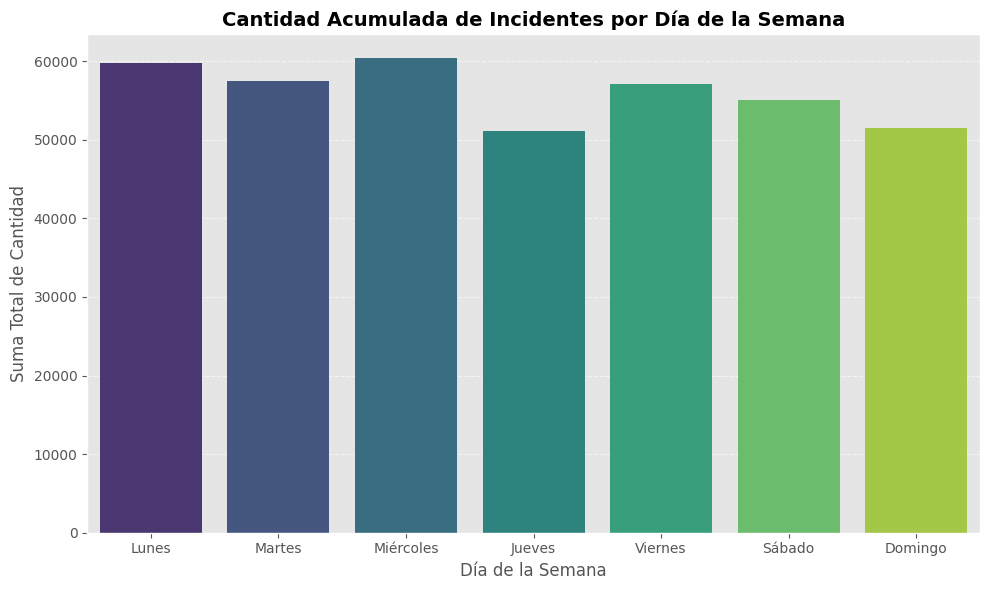

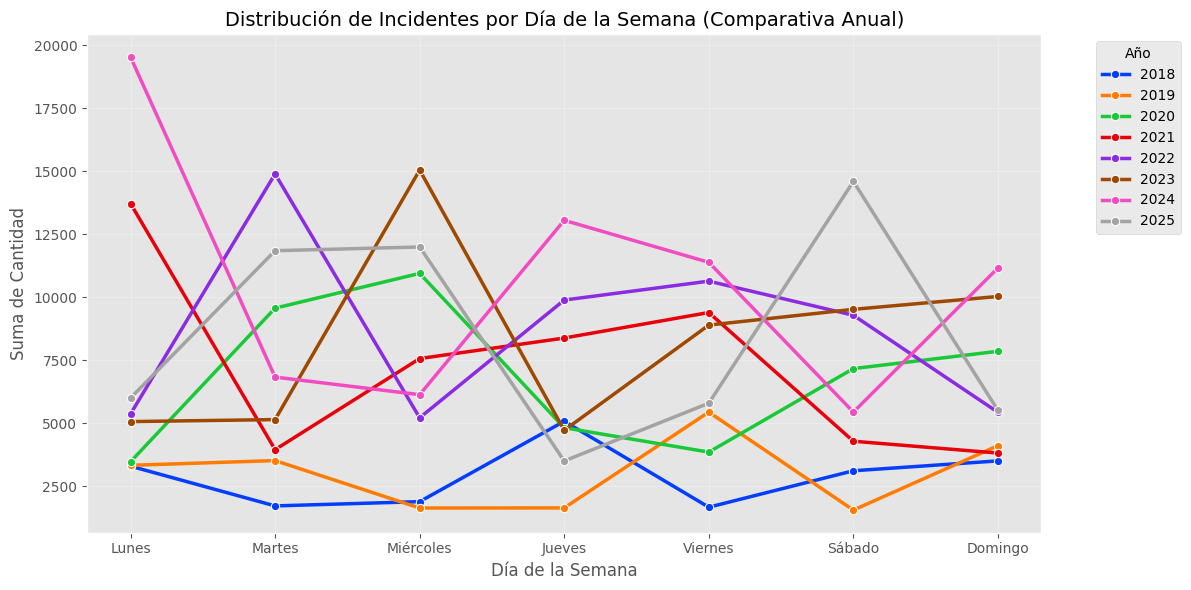

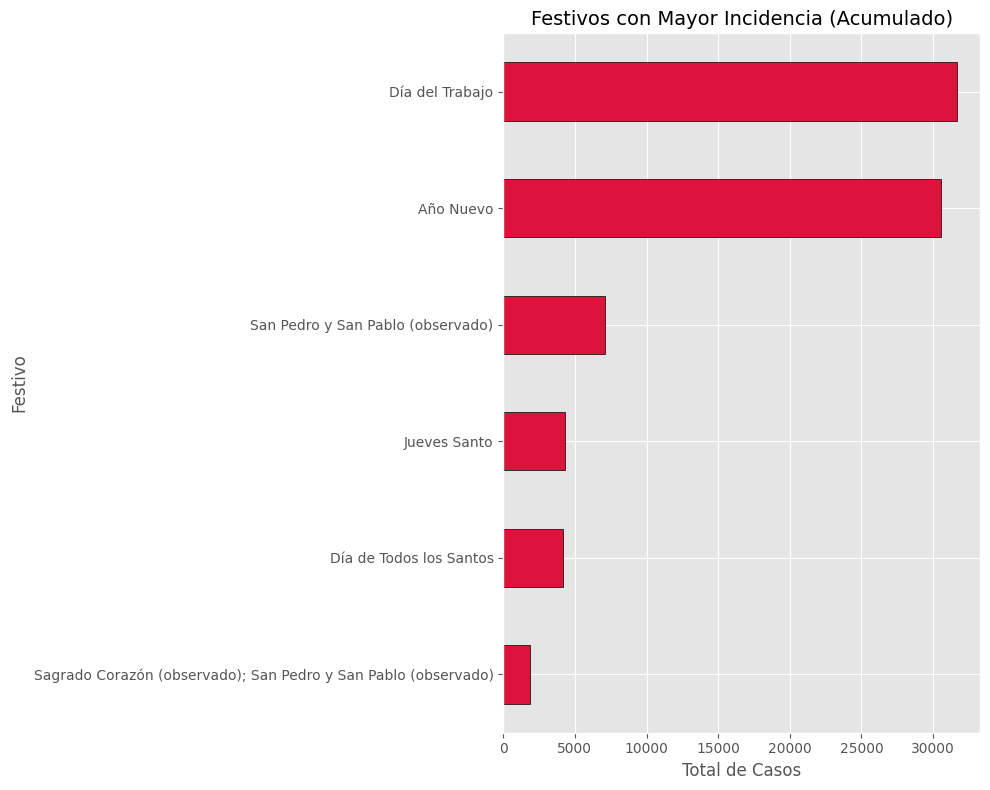

--- RESUMEN DE IMPACTO: DÍAS ORDINARIOS VS FESTIVOS POR AÑO ---
 anio  es_festivo   sum     mean
 2018       False 17002 1.578205
 2018        True  3322 1.584924
 2019       False 16224 1.620132
 2019        True  5057 1.643484
 2020       False 41194 1.934263
 2020        True  6523 1.799448
 2021       False 33185 1.818356
 2021        True 17957 1.914801
 2022       False 51124 1.958549
 2022        True  9620 1.896314
 2023       False 49053 2.323796
 2023        True  9390 2.094112
 2024       False 54555 2.950833
 2024        True 18994 1.651796
 2025       False 50510 2.901206
 2025        True  8757 2.595436


In [18]:

###############################################################################################
# CONFIGURACIÓN DE FESTIVOS Y CREACIÓN DE VARIABLES DE SEGMENTACIÓN PARA ANÁLISIS TEMPORALES. #
###############################################################################################


# 1. Configuración de festivos (Colombia) y limpieza previa
co_holidays = holidays.Colombia()
# Aseguramos que 'fecha' sea datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Creación de variables de segmentación
df['es_festivo'] = df['fecha'].apply(lambda x: x in co_holidays)
df['nombre_festivo'] = df['fecha'].apply(lambda x: co_holidays.get(x) if x in co_holidays else 'Día Ordinario')
df['anio'] = df['fecha'].dt.year
df['trimestre_nombre'] = 'Q' + df['fecha'].dt.quarter.astype(str)




########################
# VISUALIZACIÓN ANUAL. #
########################


# --- VISUALIZACIÓN 1: EVOLUCIÓN ANUAL ---
plt.figure(figsize=(10, 6))
resumen_anual = df.groupby('anio')['cantidad'].sum().reset_index()
sns.barplot(data=resumen_anual, x='anio', y='cantidad', palette='Blues_d')
plt.title('Total de Casos por Año', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de Incidentes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


######################################
# VISUALIAZACIÓN TRIMESTRAL POR AÑO. #
######################################


plt.figure(figsize=(12, 6))
resumen_trimestre = df.groupby(['anio', 'trimestre_nombre'])['cantidad'].sum().reset_index()

# Se agrega el parámetro 'palette' para maximizar el contraste entre años
sns.lineplot(data=resumen_trimestre, 
             x='trimestre_nombre', 
             y='cantidad', 
             hue='anio', 
             marker='o', 
             linewidth=2.5, 
             palette='bright') 

plt.title('Dinámica Trimestral: Comparativa por Año', fontsize=14)
plt.xlabel('Trimestre')
plt.ylabel('Suma de Cantidad')
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


############################################
# SEGEMENTACIÓN CASOS POR DÍA DE LA SEMANA #
############################################

# 1. Asegurar el orden cronológico de los días
df['dia_semana'] = df['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=orden_dias, ordered=True)

# 2. Agrupar por día de la semana (Suma total acumulada)
resumen_dias_total = df.groupby('dia_semana', observed=False)['cantidad'].sum().reset_index()

# 3. Visualización de Barras
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_dias_total, 
            x='dia_semana', 
            y='cantidad', 
            palette='viridis') # Una paleta degradada para resaltar el volumen

# Personalización
plt.title('Cantidad Acumulada de Incidentes por Día de la Semana', fontsize=14, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Suma Total de Cantidad')

# Traducción de etiquetas para claridad
plt.xticks(ticks=range(7), labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##########################
# DIAS CON CASOS POR AÑO #
##########################

# 1. Asegurar el orden cronológico de los días
df['dia_semana'] = df['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=orden_dias, ordered=True)

# 2. Agrupar datos
resumen_dias = df.groupby(['anio', 'dia_semana'], observed=False)['cantidad'].sum().reset_index()

# 3. Visualización
plt.figure(figsize=(12, 6))
sns.lineplot(data=resumen_dias, 
             x='dia_semana', 
             y='cantidad', 
             hue='anio', 
             marker='o', 
             linewidth=2.5, 
             palette='bright')

# Personalización y traducción de etiquetas
plt.title('Distribución de Incidentes por Día de la Semana (Comparativa Anual)', fontsize=14)
plt.xlabel('Día de la Semana')
plt.ylabel('Suma de Cantidad')
plt.xticks(ticks=range(7), labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#############################################
# VISUALIZACIÓN TOP FESTIVOS CON MAS CASOS. #
#############################################

# --- VISUALIZACIÓN 3: TOP FESTIVOS CRÍTICOS ---
plt.figure(figsize=(10, 8))
top_festivos = df[df['es_festivo'] == True].groupby('nombre_festivo')['cantidad'].sum().sort_values(ascending=True).tail(10)
top_festivos.plot(kind='barh', color='crimson', edgecolor='black')
plt.title('Festivos con Mayor Incidencia (Acumulado)', fontsize=14)
plt.xlabel('Total de Casos')
plt.ylabel('Festivo')
plt.tight_layout()
plt.show()

# --- TABLA DE IMPACTO ESTRATÉGICO ---
impacto_festivos = df.groupby(['anio', 'es_festivo'])['cantidad'].agg(['sum', 'mean']).reset_index()
print("--- RESUMEN DE IMPACTO: DÍAS ORDINARIOS VS FESTIVOS POR AÑO ---")
print(impacto_festivos.to_string(index=False))



Gráficos esenciales de tiempo que miden el fenómeno en su dimensión temporal, permitiendo identificar patrones estacionales, tendencias a lo largo del tiempo y el impacto de eventos específicos (como festivos) en la incidencia de los delitos informáticos.

In [19]:
###########################################################
# EXTRACCIÓN DE TABLAS DE DATOS PARA AUDITORÍA DE GRÁFICOS #
###########################################################

print("--- 1. TABLA: EVOLUCIÓN ANUAL (Visualización 1) ---")
# Muestra el total consolidado por cada año
tabla_anual = df.groupby('anio')['cantidad'].sum().reset_index()
print(tabla_anual)
print("\n")

print("--- 2. TABLA: DINÁMICA TRIMESTRAL POR AÑO (Visualización 2) ---")
# Útil para verificar los puntos de las líneas en la comparativa interanual
tabla_trimestral = df.groupby(['anio', 'trimestre_nombre'])['cantidad'].sum().unstack(fill_value=0)
print(tabla_trimestral)
print("\n")

print("--- 3. TABLA: ACUMULADO POR DÍA DE LA SEMANA (Visualización de Barras) ---")
# Verifica el peso histórico de cada día (Lunes-Domingo)
tabla_dias_total = df.groupby('dia_semana', observed=False)['cantidad'].sum().reset_index()
print(tabla_dias_total)
print("\n")

print("--- 4. TABLA: COMPARATIVA DIARIA POR AÑO (Visualización de Líneas) ---")
# Muestra cómo se distribuye la cantidad cada año según el día
tabla_dias_anio = df.groupby(['anio', 'dia_semana'], observed=False)['cantidad'].sum().unstack(fill_value=0)
print(tabla_dias_anio)
print("\n")

print("--- 5. TABLA: TOP 10 FESTIVOS MÁS CRÍTICOS (Visualización Horizontal) ---")
# Muestra los valores exactos de los festivos con mayor incidencia
tabla_top_festivos = df[df['es_festivo'] == True].groupby('nombre_festivo')['cantidad'].sum().sort_values(ascending=False).head(10)
print(tabla_top_festivos)

--- 1. TABLA: EVOLUCIÓN ANUAL (Visualización 1) ---
   anio  cantidad
0  2018     20324
1  2019     21281
2  2020     47717
3  2021     51142
4  2022     60744
5  2023     58443
6  2024     73549
7  2025     59267


--- 2. TABLA: DINÁMICA TRIMESTRAL POR AÑO (Visualización 2) ---
trimestre_nombre     Q1     Q2     Q3     Q4
anio                                        
2018               5000   5151   5259   4914
2019               4827   4710   5237   6507
2020               7993  11109  13361  15254
2021              14812  12551  11845  11934
2022              14800  15993  16403  13548
2023              14085  14528  15434  14396
2024              17263  18258  21099  16929
2025              15075  13820  18859  11513


--- 3. TABLA: ACUMULADO POR DÍA DE LA SEMANA (Visualización de Barras) ---
  dia_semana  cantidad
0     Monday     59815
1    Tuesday     57506
2  Wednesday     60458
3   Thursday     51125
4     Friday     57104
5   Saturday     54999
6     Sunday     51460


--- 4. 

Tablas para la inspección de datos y validación de gráficos.

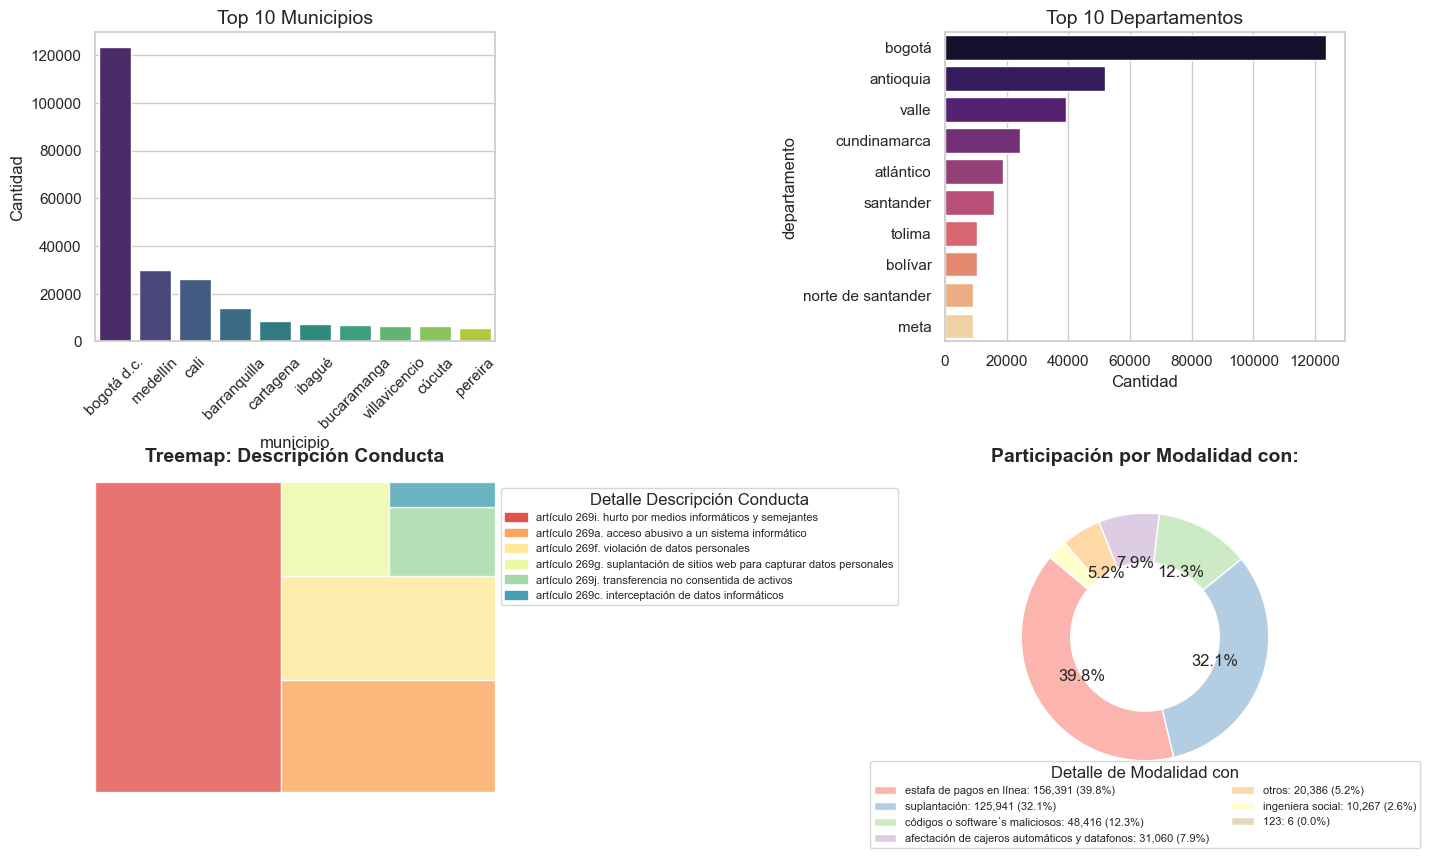

In [20]:


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2)

# 1. BARRAS VERTICALES: Municipio por cantidad (Top 10)
top_mun = df.groupby('municipio')['cantidad'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_mun.index, y=top_mun.values, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Top 10 Municipios', fontsize=14)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylabel('Cantidad')

# 2. BARRAS HORIZONTALES: Departamento por cantidad (Top 10)
top_depto = df.groupby('departamento')['cantidad'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_depto.values, y=top_depto.index, palette='magma', ax=axes[0,1])
axes[0,1].set_title('Top 10 Departamentos', fontsize=14)
axes[0,1].set_xlabel('Cantidad')

# 3. TREEMAP: Cantidad por Modalidad
mod_top = df.groupby('descripcion_conducta')['cantidad'].sum().sort_values(ascending=False)
colores = sns.color_palette("Spectral", len(mod_top))
squarify.plot(sizes=mod_top.values, alpha=0.8, color=colores, ax=axes[1,0])
axes[1,0].legend(
    handles=[plt.Rectangle((0,0),1,1,color=c) for c in colores],
    labels=list(mod_top.index),
    title="Detalle Descripción Conducta",
    loc='upper left',
    bbox_to_anchor=(1,1),
    fontsize=8
)
axes[1,0].set_title('Treemap: Descripción Conducta', fontsize=14, fontweight='bold', pad=15)
axes[1,0].axis('off')

# 4. GRÁFICO DE ANILLO: Cantidad por Modalidad_con
mod_con_data = df.groupby('modalidad_con')['cantidad'].sum().sort_values(ascending=False)
total = mod_con_data.sum()
colores_anillo = sns.color_palette("Pastel1", len(mod_con_data))

wedges, texts, autotexts = axes[1,1].pie(
    mod_con_data,
    startangle=140,
    colors=colores_anillo,
    wedgeprops={'width':0.4},
    autopct=lambda p: f'{p:.1f}%' if p>5 else ''  # solo mostrar % si >5%
)

legend_labels = [
    f'{label}: {valor:,} ({(valor/total)*100:.1f}%)'
    for label, valor in mod_con_data.items()
]

axes[1,1].legend(
    wedges,
    legend_labels,
    title="Detalle de Modalidad con",
    loc='lower center',
    bbox_to_anchor=(0.5,-0.2),
    fontsize=8,
    frameon=True,
    ncol=2
)
axes[1,1].set_title('Participación por Modalidad con:', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # espacio extra para la leyenda inferior
plt.show()


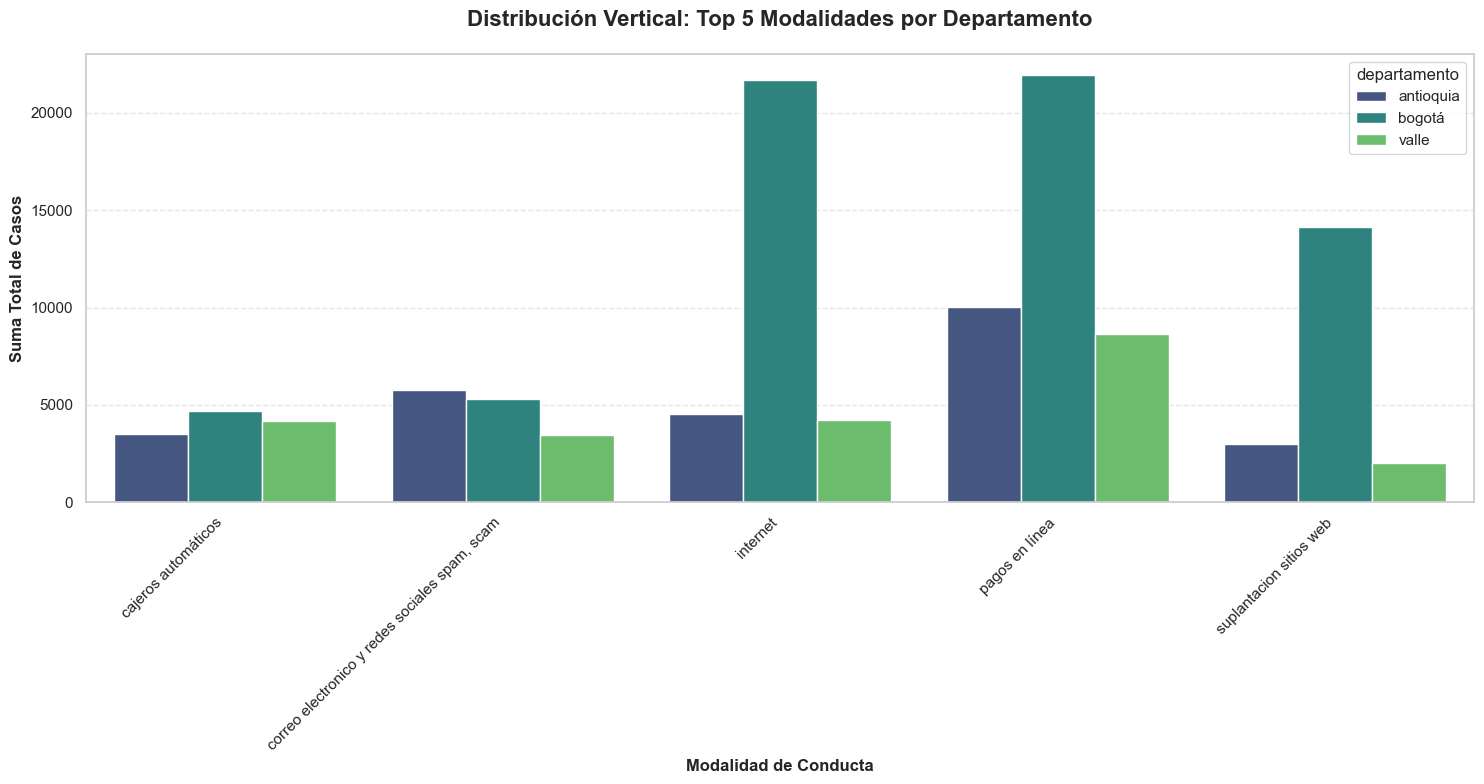

In [21]:

# 1. Identificamos los 3 departamentos líderes
top_3_depto = df.groupby('departamento')['cantidad'].sum().nlargest(3).index

# 2. Filtramos el DataFrame original para esos departamentos
df_top_deptos = df[df['departamento'].isin(top_3_depto)]

# 3. Identificamos las 5 modalidades más frecuentes en esos departamentos
top_5_modalidad = df_top_deptos.groupby('modalidad')['cantidad'].sum().nlargest(5).index

# 4. Filtramos el resumen final y reseteamos el índice para Seaborn
resumen_grafico = df_top_deptos[df_top_deptos['modalidad'].isin(top_5_modalidad)]
resumen_grafico = resumen_grafico.groupby(['departamento', 'modalidad'])['cantidad'].sum().reset_index()

# --- VISUALIZACIÓN EN BARRAS VERTICALES ---
plt.figure(figsize=(15, 8))

# Cambiamos x e y, y mantenemos hue para la comparativa por departamento
sns.barplot(
    data=resumen_grafico,
    x='modalidad',      # Variable categórica en la base
    y='cantidad',       # Altura de la barra
    hue='departamento', # Diferenciación por colores
    palette='viridis'   # Una paleta clara y profesional
)

# --- ESTÉTICA Y LEGIBILIDAD ---
plt.title('Distribución Vertical: Top 5 Modalidades por Departamento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Modalidad de Conducta', fontsize=12, fontweight='bold')
plt.ylabel('Suma Total de Casos', fontsize=12, fontweight='bold')

# Rotamos las etiquetas del eje X para evitar que se solapen
plt.xticks(rotation=45, ha='right')

# Añadimos una cuadrícula ligera en el eje Y para facilitar la lectura de valores
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajuste fino para que no se corte el texto de abajo
plt.tight_layout()
plt.show()

Herramientas de vizualización de los datos mas relevantes por departmento y modalidad, para identificar patrones y tendencias en la distribución de los casos. Se incluyen gráficos de barras, treemap y gráficos de anillo para mostrar la participación relativa de cada modalidad dentro de los departamentos más afectados. 

In [22]:
# ANÁLISIS DE HIPÓTESIS: RELACIÓN ENTRE "departamento" Y "modalidad_con".

# 1. Crear tabla de contingencia
contingency_table = pd.crosstab(df['departamento'], df['modalidad_con'])

print("Tabla de contingencia (departamento vs modalidad_con):")
display(contingency_table.head())

# 2. Aplicar test Chi-cuadrado
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("-" * 50)
print("Resultados del test Chi-cuadrado:")
print(f" Chi-cuadrado: {chi2:.2f}")
print(f" Grados de libertad: {dof}")
print(f" Valor p: {p:.4e}")

# 3. Interpretación
alpha = 0.05
print("-" * 50)
if p < alpha:
    print(" RESULTADO: Se rechaza la hipótesis nula (H₀).")
    print(" CONCLUSIÓN: Existen diferencias significativas en la distribución de modalidades entre regiones.")
else:
    print(" RESULTADO: No se rechaza la hipótesis nula (H₀).")
    print(" CONCLUSIÓN: No se encontraron diferencias significativas.")


Tabla de contingencia (departamento vs modalidad_con):


modalidad_con,123,afectación de cajeros automáticos y datafonos,códigos o software´s maliciosos,estafa de pagos en línea,ingeniera social,otros,suplantación
departamento,,,,,,,
amazonas,0,6,17,39,5,2,31
antioquia,1,1999,3998,8426,1383,1380,10526
arauca,0,96,121,268,4,31,232
atlántico,0,705,1183,3033,177,520,3764
bogotá,1,1113,6162,7612,1360,1223,11546


--------------------------------------------------
Resultados del test Chi-cuadrado:
 Chi-cuadrado: 6992.79
 Grados de libertad: 192
 Valor p: 0.0000e+00
--------------------------------------------------
 RESULTADO: Se rechaza la hipótesis nula (H₀).
 CONCLUSIÓN: Existen diferencias significativas en la distribución de modalidades entre regiones.


Prueba de hipótesis: Relación entre "departamento" y "modalidad_con" usando el test Chi-cuadrado. 
Se pretende entender si la distribución de modalidades de conducta varía significativamente entre departamentos, lo que podría indicar patrones regionales en la naturaleza de los incidentes. 
 
*INTERPRETACIÓN ANÁLISIS DE HIPÓTESIS:*
Tras el rechazo de la hipótesis nula, cuyo planteamiento era que todos los departamentos presentaban patrones iguales en cuanto a hechos delictivos, trás la prueba de chi-cuadrado ser verifica que cada cada departamento presenta su patron individual de hechos delictivos. Esto sugiere que se debe abordar la problemática en cada departamento de manera diferente conforme a sus caractéristicas. 

In [ ]:
# GENERACIÓN DE ARCHIVO CSV LIMPIO PARA DESPLEGAR MODELOS DE MACHINE LEARNING, PROCESADO EN POWER BI
# Y AUDITORÍA EXTERNA O USO FUTURO.

df.to_csv('delitos_banca.csv', index=False)